Imports

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, SnowballStemmer, LancasterStemmer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
sns.set_theme(style="whitegrid", palette="muted")
RANDOM_STATE = 42
import nltk
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mahha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


##### Data Acquisition & Standardizing Labels:

Given we're working on two different datasets, we need to bring them together into a "Common Data Format", which prevents us from writing redundant code later. We'll create a unified `text` and `label` column for both

Dataset 1:

In [105]:
df_true = pd.read_csv('data/News _dataset/True.csv')
df_fake = pd.read_csv('data/News _dataset/Fake.csv')
df_true['label'] = 1
df_fake['label'] = 0
data1 = pd.concat([df_true, df_fake]).sample(frac=0.1, random_state=RANDOM_STATE)
text_col = "text" if "text" in data1.columns else data1.columns[0]
data1 = data1[[text_col, "label"]].dropna().rename(columns={text_col: "text"})
data1.describe()

,label
count,4490.000000
mean,0.484633
std,0.499819
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


Dataset 2:

In [106]:
data2 = pd.read_csv('data/df_file.csv')
data2 = data2.rename(columns={'Text': 'text', 'Label': 'label'})
data2 = data2[['text', 'label']].dropna()
data2.describe()

,label
count,2225.000000
mean,2.027416
std,1.438694
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,4.000000


Dataset 1 Class Distribution:
 label
0    51.536748
1    48.463252
Name: proportion, dtype: float64
Dataset 2 Class Distribution:
 label
1    22.966292
4    22.921348
0    18.741573
2    18.022472
3    17.348315
Name: proportion, dtype: float64


C:\Users\mahha\AppData\Local\Temp\ipykernel_26988\3486866439.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=data1, ax=ax[0], palette="muted").set_title("Dataset 1: Binary Distribution")
C:\Users\mahha\AppData\Local\Temp\ipykernel_26988\3486866439.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=data2, ax=ax[1], palette="muted").set_title("Dataset 2: Multi-class Distribution")


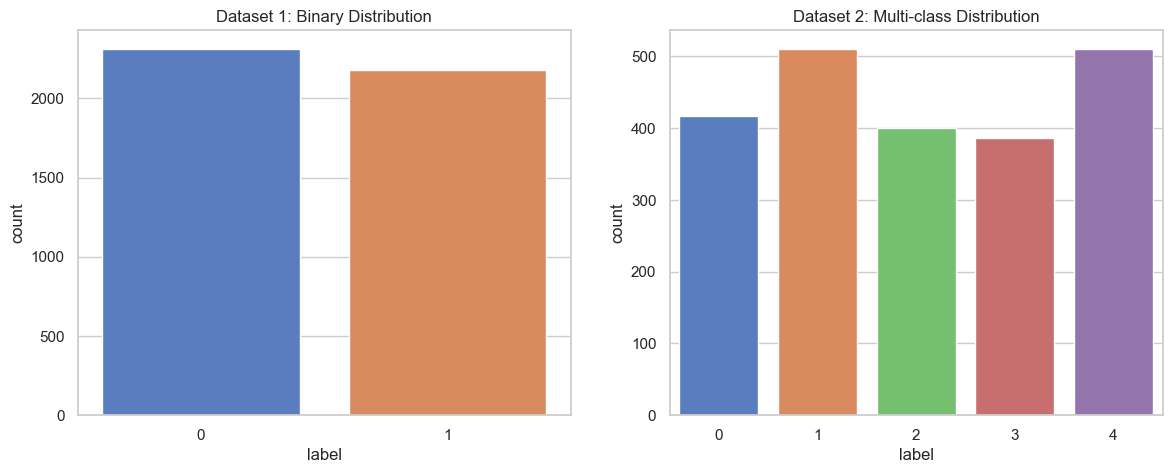

In [107]:
print("Dataset 1 Class Distribution:\n", data1['label'].value_counts(normalize=True) * 100)
print("Dataset 2 Class Distribution:\n", data2['label'].value_counts(normalize=True) * 100)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='label', data=data1, ax=ax[0], palette="muted").set_title("Dataset 1: Binary Distribution")
sns.countplot(x='label', data=data2, ax=ax[1], palette="muted").set_title("Dataset 2: Multi-class Distribution")
plt.show()

### Dataset Balance Analysis:

These count plots illustrate the distribution of target labels across both datasets.

**Dataset 1**
- Highly Balanced.
- The count for class `0` and class `1` is nearly identical (both exceeding 2,000 samples).

**Dataset 2**
- Well Balanced.
- While there are minor fluctuations (class `1` and `4` have slightly higher counts than class `3`), all five classes sit within a healthy range (roughly between 400 and 500 samples each).

### Preprocessing

The following function removes the noise (numbers, punctuation, stopwords) that doesn't contribute to the core meaning of the sentence

In [108]:
def backbone_cleaner(text):
    text = str(text).lower()
    text = re.sub(r'\d+', ' numtoken ', text)
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

In [109]:
data1['cleaned_base'] = data1['text'].apply(backbone_cleaner)
data2['cleaned_base'] = data2['text'].apply(backbone_cleaner)

In [110]:
data1.head()

,text,label,cleaned_base
799,"Donald Trump s White House is in chaos, and th...",0,donald trump white house chaos trying cover ru...
6500,Now that Donald Trump is the presumptive GOP n...,0,donald trump presumptive gop nominee time reme...
3590,Mike Pence is a huge homophobe. He supports ex...,0,mike pence huge homophobe supports exgay conve...
1377,SAN FRANCISCO (Reuters) - California Attorney ...,1,san francisco reuters california attorney gene...
11059,Twisted reasoning is all that comes from Pelos...,0,twisted reasoning comes pelosi days especially...


In [111]:
data2.head()

,text,label,cleaned_base
0,Budget to set scene for election\n \n Gordon B...,0,budget set scene election gordon brown seek pu...
1,Army chiefs in regiments decision\n \n Militar...,0,army chiefs regiments decision military chiefs...
2,Howard denies split over ID cards\n \n Michael...,0,howard denies split id cards michael howard de...
3,Observers to monitor UK election\n \n Minister...,0,observers monitor uk election ministers invite...
4,Kilroy names election seat target\n \n Ex-chat...,0,kilroy names election seat target exchat show ...


#### Implementing the Stemming Variants

Here we move to the part in which we compare Control (No Stemming) against three major algorithms: Porter, Snowball, Lancaster.

We should note the "Aggression Spectrum": Porter(Mild) < Snowball (Balanced) < Lancaster (Extreme)

In [112]:
p_stemmer = PorterStemmer()
s_stemmer = SnowballStemmer('english')
l_stemmer = LancasterStemmer()

In [113]:
def apply_stemming(text, stemmer):
    words = text.split()
    if stemmer == 'porter':
        return " ".join([p_stemmer.stem(w) for w in words])
    elif stemmer == 'snowball':
        return " ".join([s_stemmer.stem(w) for w in words])
    elif stemmer == 'lancaster':
        return " ".join([l_stemmer.stem(w) for w in words])
    return text

In [114]:
stemmer = ['none', 'porter', 'snowball', 'lancaster']
data1_variants = {m: data1['cleaned_base'].apply(lambda x: apply_stemming(x, m)) for m in stemmer}
data2_variants = {m: data2['cleaned_base'].apply(lambda x: apply_stemming(x, m)) for m in stemmer}

In [115]:
data1_variants['porter'].head()

799      donald trump white hous chao tri cover russia ...
6500     donald trump presumpt gop nomine time rememb c...
3590     mike penc huge homophob support exgay convers ...
1377     san francisco reuter california attorney gener...
11059    twist reason come pelosi day especi numtoken p...
Name: cleaned_base, dtype: str

### Benchmarking with Random Forest

We use TF-IDF vectorization to convert text into numbers. We then train a RF (100 trees) on each version. We track `Vocab_Size` to see how much each stemmer "shrinks" the data

In [116]:
def run_benchmarks(variants_dict, labels):
    results = []
    
    for method, texts in variants_dict.items():
        X_train_raw, X_test_raw, y_train, y_test = train_test_split(texts, labels, test_size=0.2, random_state=RANDOM_STATE)
        
        tfidf = TfidfVectorizer()
        
        X_train = tfidf.fit_transform(X_train_raw)
        X_test = tfidf.transform(X_test_raw) 
        
        rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE)
        rf.fit(X_train, y_train)
        
        # Evaluate
        preds = rf.predict(X_test)
        results.append({
            'Stemmer': method.capitalize(),
            'Accuracy': accuracy_score(y_test, preds),
            'F1 Score': f1_score(y_test, preds, average='weighted'),
            'Vocab Size': len(tfidf.vocabulary_) 
        })
        
    return pd.DataFrame(results)


In [117]:
rest1_df = run_benchmarks(data1_variants, data1['label'])
rest2_df = run_benchmarks(data2_variants, data2['label'])

In [118]:
rest1_df.head()

,Stemmer,Accuracy,F1 Score,Vocab Size
0,None,0.973274,0.973277,52869
1,Porter,0.973274,0.973277,40563
2,Snowball,0.977728,0.977731,40385
3,Lancaster,0.977728,0.977730,36133


In [119]:
rest2_df.head()

,Stemmer,Accuracy,F1 Score,Vocab Size
0,None,0.957303,0.957265,28309
1,Porter,0.959551,0.959483,19342
2,Snowball,0.964045,0.963897,19290
3,Lancaster,0.946067,0.946093,16816


### Visualization:

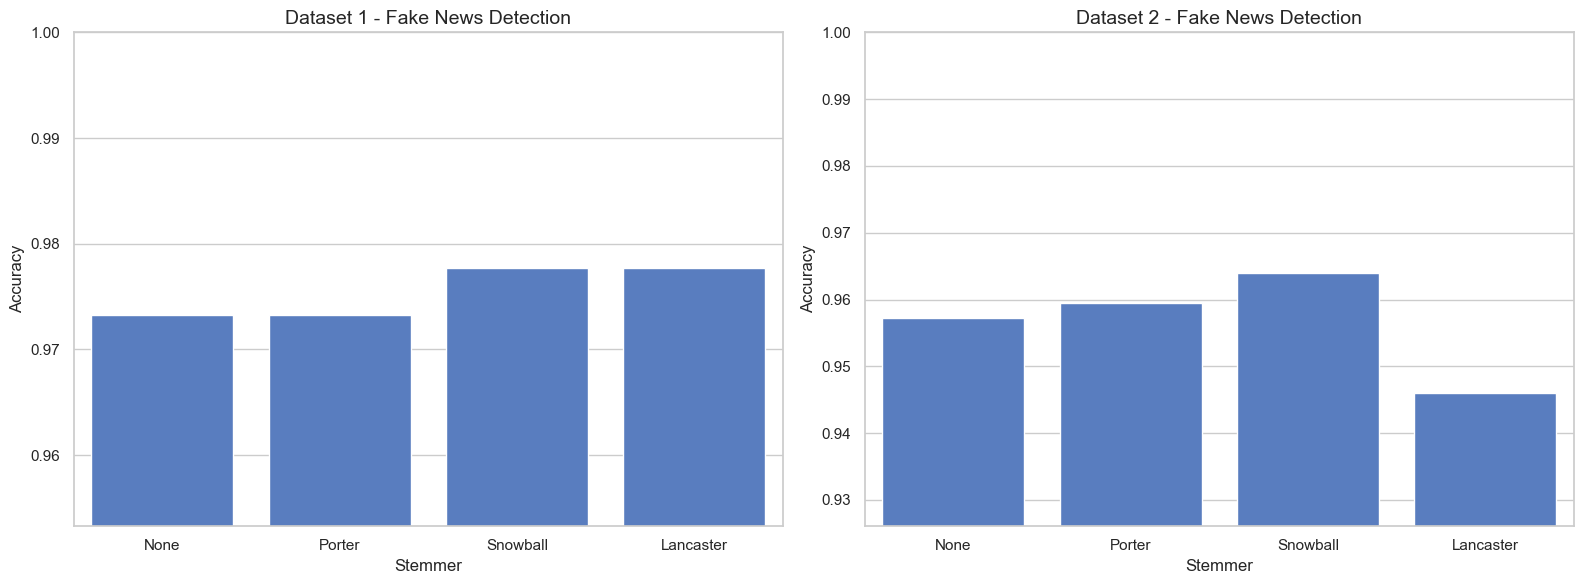

In [120]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x='Stemmer', y='Accuracy', data=rest1_df, ax=ax[0])
ax[0].set_title('Dataset 1 - Fake News Detection', fontsize=14)
ax[0].set_ylim(min(rest1_df['Accuracy']) - 0.02, 1.0)

sns.barplot(x='Stemmer', y='Accuracy', data=rest2_df, ax=ax[1])
ax[1].set_title('Dataset 2 - Fake News Detection', fontsize=14)
ax[1].set_ylim(min(rest2_df['Accuracy']) - 0.02, 1.0)
plt.tight_layout()
plt.show()

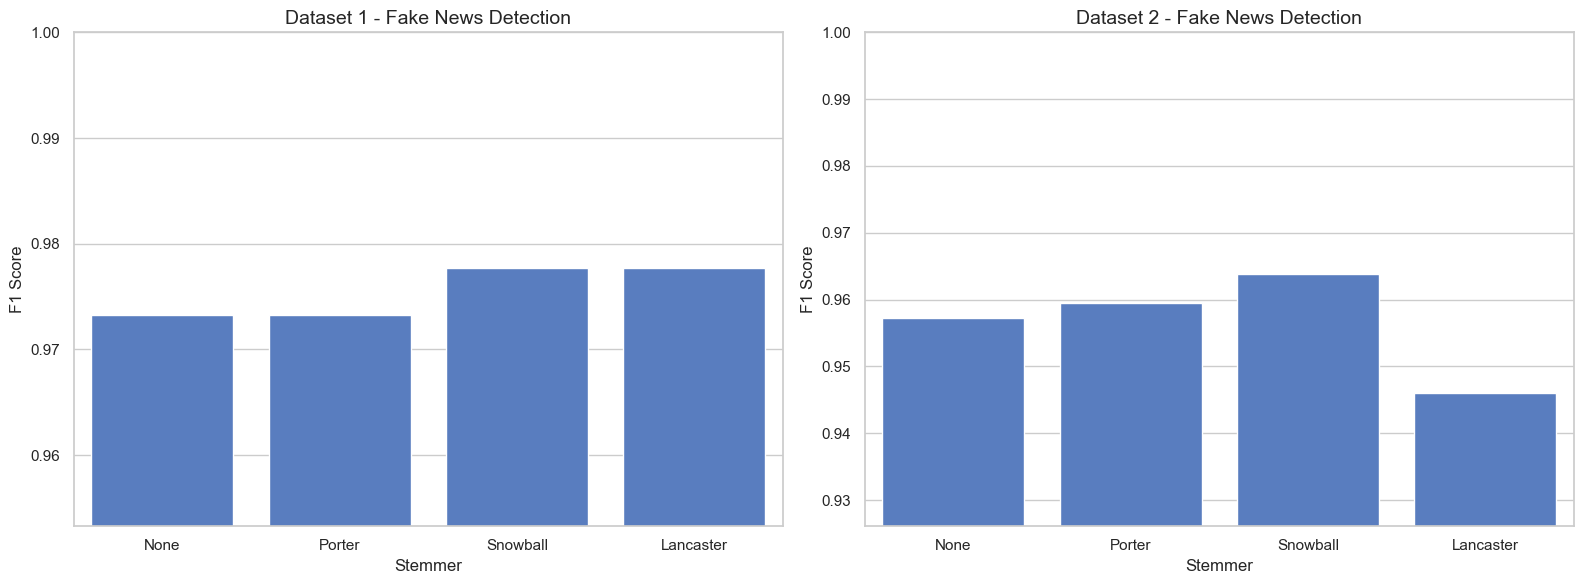

In [121]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x='Stemmer', y='F1 Score', data=rest1_df, ax=ax[0])
ax[0].set_title('Dataset 1 - Fake News Detection', fontsize=14)
ax[0].set_ylim(min(rest1_df['F1 Score']) - 0.02, 1.0)

sns.barplot(x='Stemmer', y='F1 Score', data=rest2_df, ax=ax[1])
ax[1].set_title('Dataset 2 - Fake News Detection', fontsize=14)
ax[1].set_ylim(min(rest2_df['F1 Score']) - 0.02, 1.0)
plt.tight_layout()
plt.show()

In [122]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline

In [123]:
def visualize_leakage_impact(texts, labels, dataset_name="Dataset"):
    rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    tfidf_leaked = TfidfVectorizer()
    X_leaked = tfidf_leaked.fit_transform(texts) 
    leaked_scores = cross_val_score(rf, X_leaked, labels, cv=cv, scoring='f1_weighted')
    
    strict_pipeline = Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('rf', rf)
    ])
    strict_scores = cross_val_score(strict_pipeline, texts, labels, cv=cv, scoring='f1_weighted')
    
    plot_data = pd.DataFrame({
        'Methodology': ['Leaked (Pre-fit TFIDF)'] * 5 + ['Strict (Pipeline TFIDF)'] * 5,
        'F1 Score': list(leaked_scores) + list(strict_scores)
    })
    
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Methodology', y='F1 Score', data=plot_data, palette='pastel', width=0.5)
    sns.stripplot(x='Methodology', y='F1 Score', data=plot_data, color='black', alpha=0.6, jitter=True)
    
    plt.title(f'Data Leakage Impact on Model Performance ({dataset_name})', fontsize=14, fontweight='bold')
    plt.ylabel('Weighted F1 Score', fontsize=12)
    plt.xlabel('', fontsize=12)
    
    strict_mean = strict_scores.mean()
    plt.axhline(strict_mean, color='red', linestyle='--', alpha=0.5, label=f'True Mean F1: {strict_mean:.4f}')
    plt.legend()
    plt.tight_layout()
    plt.show()

This function performs a comparison between 2 different validation approaches:
1. Leaked: Fits `TfidfVectorizer` on the entire dataset before splitting. which results in a data leakage, but gives us higher metrics.
2. Strict: Uses a Pipeline to ensure TF-IDF is fitted on the training folds only during cross-validation.

C:\Users\mahha\AppData\Local\Temp\ipykernel_26988\2524058064.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Methodology', y='F1 Score', data=plot_data, palette='pastel', width=0.5)


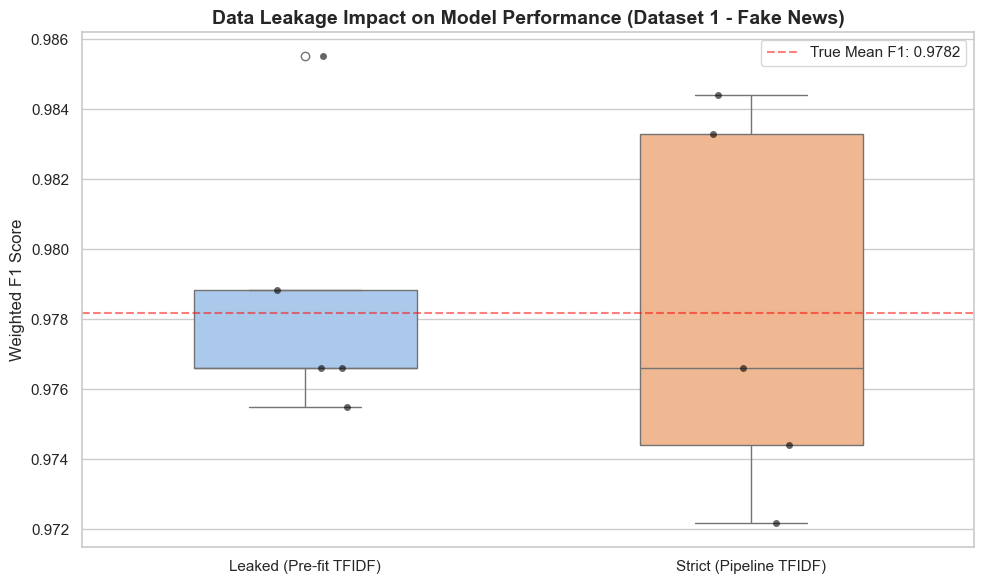

C:\Users\mahha\AppData\Local\Temp\ipykernel_26988\2524058064.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Methodology', y='F1 Score', data=plot_data, palette='pastel', width=0.5)


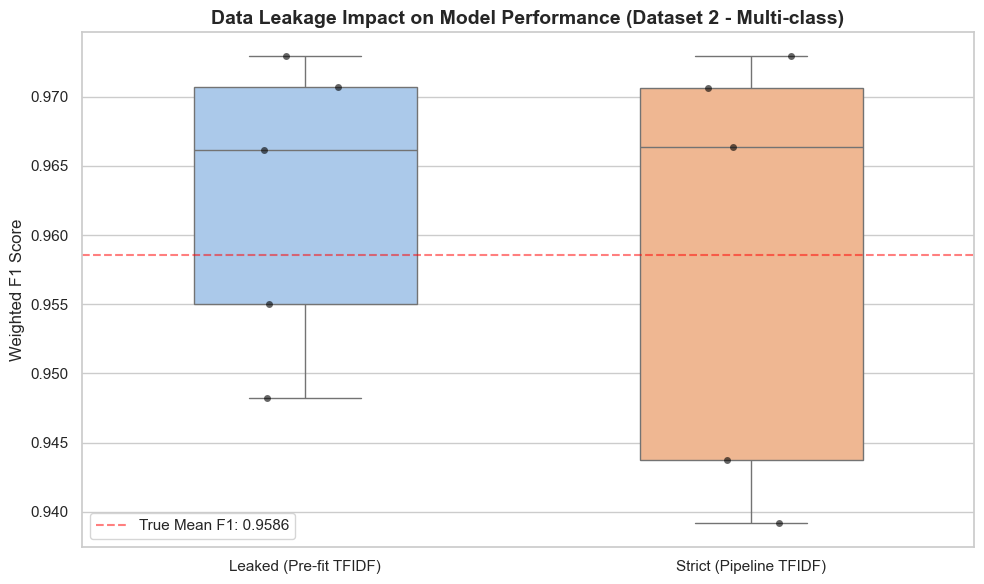

In [124]:
visualize_leakage_impact(data1['cleaned_base'], data1['label'], dataset_name="Dataset 1 - Fake News")
visualize_leakage_impact(data2['cleaned_base'], data2['label'], dataset_name="Dataset 2 - Multi-class")

### Visual Indicators:
* The Blue Box: The scores are high and show low variance because a data leakage is present, therefore the model has already been trained on the test data too.

* The Orange Box: This is the true generalization of the model, the scores are lower and more variant.

* The Red Line: Marks the mean F1-Score calculated via 5-folds cross-validation. the gap between the blue median and this line quantifies the bias removed by fixing the leakage.

### Conclusion:
After evaluating performances across binary/multi-class datasets while controlling for data leakage, the **Snowball Stemmer** is the stemmers that provides balance of dimensionality reduction and predictive power, proving more stable than the porter stemmer and less destructive than the lancaster stemmer.